<a href="https://colab.research.google.com/github/sohanchelekar276/MRT-IP-Assignment-4/blob/main/MRT_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

# This makes the plots look bigger
plt.rcParams['figure.figsize'] = [16, 8]

def show_img(img, title="Image", cmap_type='gray'):
    plt.imshow(img, cmap=cmap_type)
    plt.title(title)
    plt.axis('off')
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


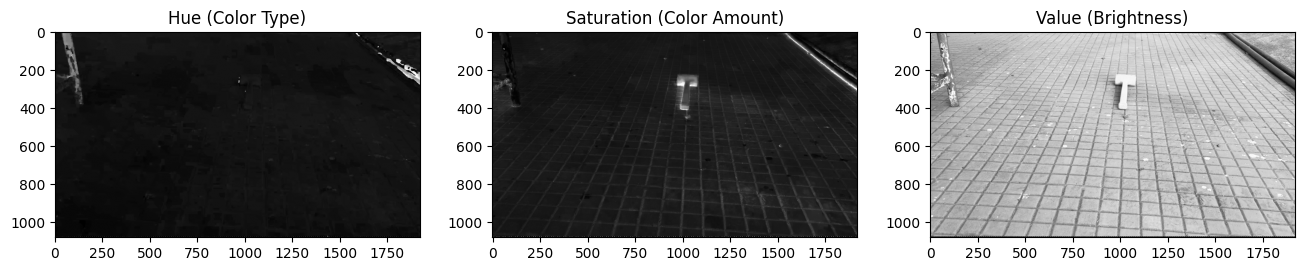

In [ ]:
# 1. Load a video and get the first frame
cap = cv2.VideoCapture('/content/drive/MyDrive/Inductions\'26/Assignment 4 - Classical CV/Mallet_videos/IMG_9110.MOV')
ret, frame = cap.read()
cap.release()

if ret:
    # 2. Convert to HSV
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # 3. Look at them side-by-side
    plt.subplot(1, 3, 1); plt.imshow(h, cmap='gray'); plt.title('Hue (Color Type)')
    plt.subplot(1, 3, 2); plt.imshow(s, cmap='gray'); plt.title('Saturation (Color Amount)')
    plt.subplot(1, 3, 3); plt.imshow(v, cmap='gray'); plt.title('Value (Brightness)')
    plt.show()
else:
    print("Could not read video. Check your path!")

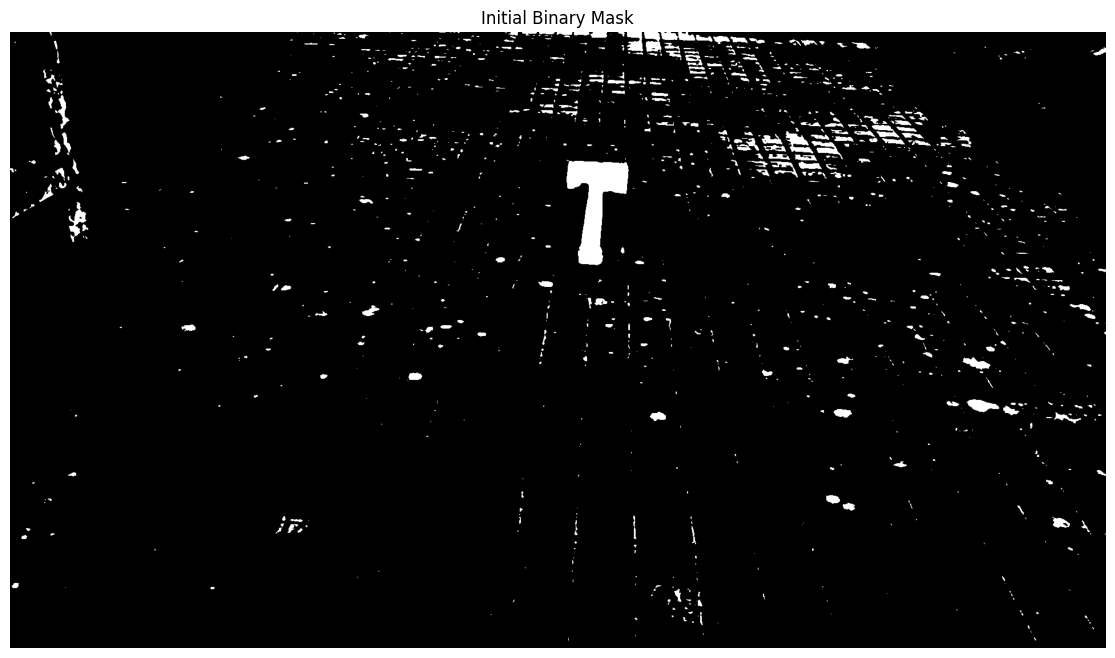

In [ ]:
# 1. Blur the S-channel to smooth out noise
# (5,5) is the kernel size. Higher numbers = more blur.
blurred_s = cv2.GaussianBlur(v, (5, 5), 0)

# 2. Apply Otsu's Thresholding
_, binary_mask = cv2.threshold(blurred_s, 220, 255, cv2.THRESH_BINARY)

# Show result
show_img(binary_mask, "Initial Binary Mask")

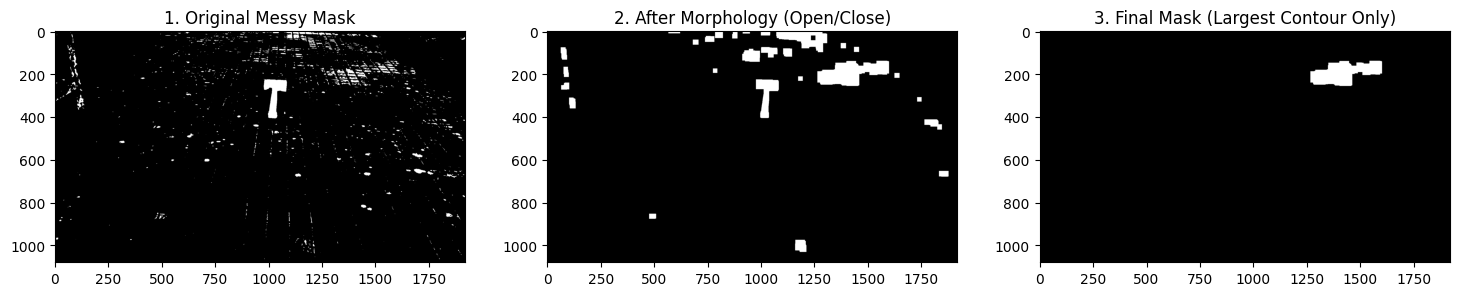

In [ ]:
# --- STEP 3: REFINEMENT ---

# 1. Define our "Brush" (Kernel)
# A 5x5 square is a standard starting point.
kernel = np.ones((3, 3), np.uint8)

# 3. Morphological CLOSING (Dilation -> Erosion)
# This fills in small black holes inside the mallet object
mask_clean = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel, iterations=10)

# 2. Morphological OPENING (Erosion -> Dilation)
# This removes the white speckles (noise) from the background
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_OPEN, kernel, iterations=10)


# --- STEP 4: KEEP ONLY THE LARGEST OBJECT ---
# Find all contours (shapes) in the mask
contours , _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Create a blank black mask to draw the final result
final_mask = np.zeros_like(mask_clean)
if contours: # Find the biggest contour by Area
  largest_contour = max(contours, key=cv2.contourArea)
# Draw only the largest contour onto the blank mask
# 255 = White, -1 = Fill inside
cv2.drawContours(final_mask, [largest_contour], -1, 255, -1)




# --- VISUALIZE ---
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(binary_mask, cmap='gray')
plt.title("1. Original Messy Mask")

plt.subplot(1, 3, 2)
plt.imshow(mask_clean, cmap='gray')
plt.title("2. After Morphology (Open/Close)")

plt.subplot(1, 3, 3)
plt.imshow(final_mask, cmap='gray')
plt.title("3. Final Mask (Largest Contour Only)")

plt.show()